# Plots of deterministic results

In [101]:
import numpy as np
from matplotlib import pyplot as plt
import scipy as sp
import scipy.special as sps

## Rate constants

In [102]:
R = 0.00888
K = 0.00772

## $\frac{F_{fast}}{A}$ plot vs. $\frac{N}{A}$

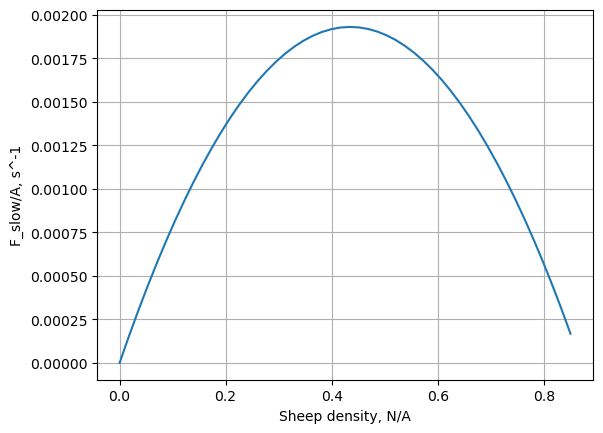

In [103]:
density = np.linspace(0, 0.85)

F_fastA = density*R - density**2 * R**2 / K

for i in range(0, F_fastA.size):
    if F_fastA[i] < 0:
        F_fastA[i]=0

f, ax = plt.subplots()

ax.plot(density, F_fastA)

ax.set_xlabel("Sheep density, N/A")
ax.set_ylabel("F_slow/A, s^-1")
ax.grid(True)

plt.show()

## $\frac{F_{slow}}{A}$ plot vs. $\frac{N}{A}$ and $T$

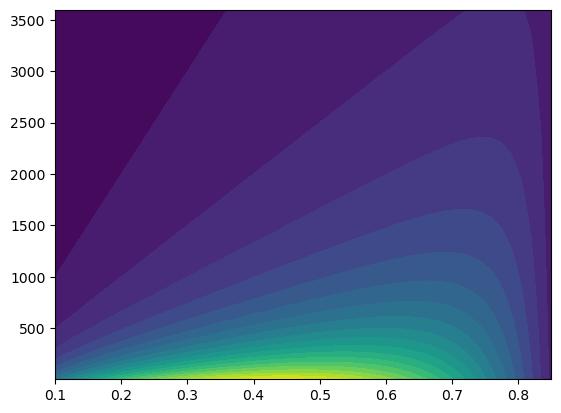

In [104]:
density = np.linspace(0.1,0.85)
T = np.linspace(1, 3600)

dd, TT = np.meshgrid(density, T)

F_slowA = dd*(1 - np.exp(-TT*R + TT*R**2*dd/K))/TT

for i in range(0, F_slowA.shape[0]):
    for j in range(0, F_slowA.shape[1]):
        if F_slowA[i][j] < 0:
            F_slowA[i][j] = 0.0001

f, ax = plt.subplots()

ax.contourf(dd, TT, F_slowA, levels=20)

plt.show()

## Optimal sheep density vs T for slow farmer

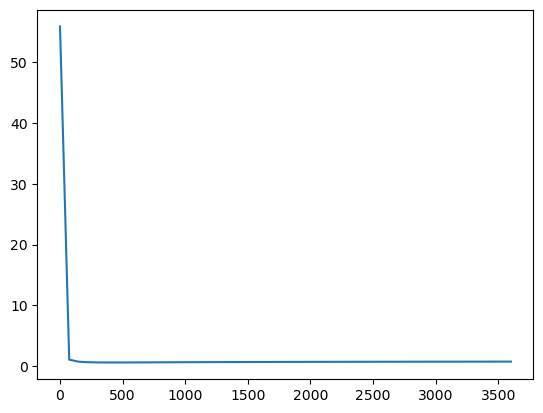

In [111]:
f, ax = plt.subplots()

T = np.linspace(1, 3600)

ax.plot(T, K*sps.lambertw(np.exp(T*R))/(T*R**2))

plt.show()

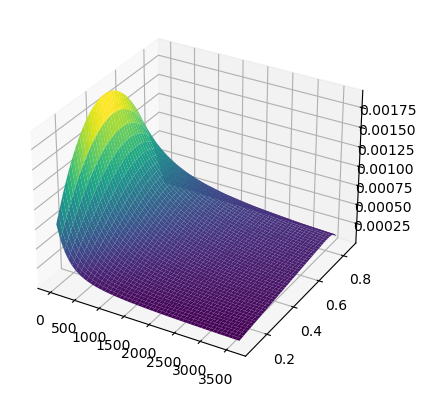

In [105]:
density = np.linspace(0.1,0.85)
T = np.linspace(1, 3600)

dd, TT = np.meshgrid(density, T)

F_slowA = dd*(1 - np.exp(-TT*R + TT*R**2*dd/K))/TT

for i in range(0, F_slowA.shape[0]):
    for j in range(0, F_slowA.shape[1]):
        if F_slowA[i][j] < 0:
            F_slowA[i][j] = 0.0001

f, ax = plt.subplots(subplot_kw=dict(projection='3d'))

ax.plot_surface(TT, dd, F_slowA, cmap="viridis")

plt.show()

## maximum $\frac{F_{slow}}{A}$ vs $T$

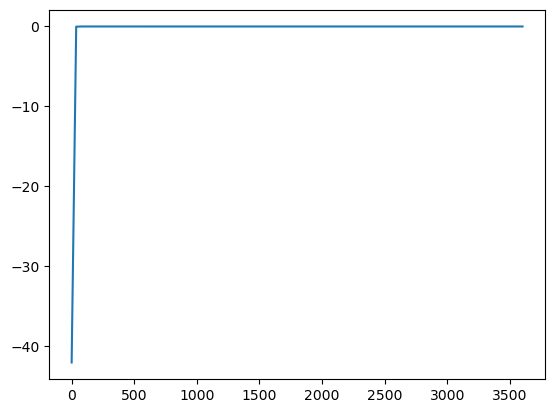

In [108]:
T = np.linspace(1, 3600, 100)

F_slowA = K*sps.lambertw(np.exp(T*R),k=0,tol=1e-10)*(1-np.exp(-T*R+sps.lambertw(np.exp(T*R),k=0,tol=1e-10)))/(R**2*T**2)

f, ax = plt.subplots()

ax.plot(T, F_slowA)

plt.show()

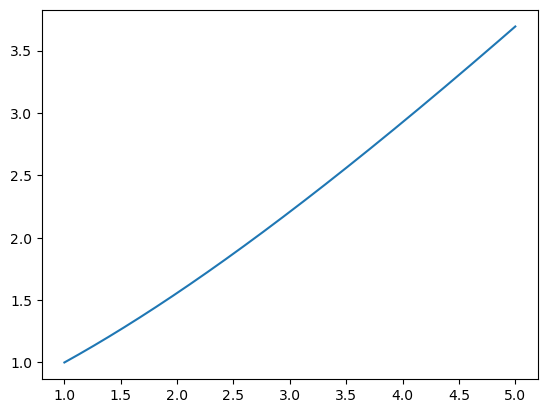

In [110]:
f, ax = plt.subplots()

ax.plot(np.linspace(1, 5, 1000), sps.lambertw(np.exp(np.linspace(1,5, 1000))))

plt.show()